In [8]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import ECHEnsbl, Univariate, CovMatrix, Obser, MagScObs, ECHModel, ECHParticleFilter, ObserVecNoise, MagObser

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.WARNING)

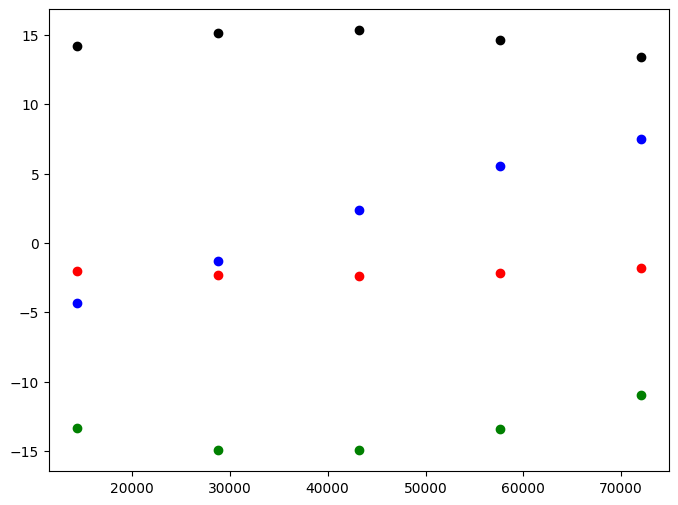

In [9]:
# Set up model priors
model = ECHModel([
    Univariate.uniform("phi", -1.0, 1.0),
    Univariate.uniform("theta", np.pi - 1.25, np.pi + 1.25),
    Univariate.constant("psi", 0.0),
    Univariate.uniform("y", -0.65, 0.65),
    Univariate.constant("delta", 1.0),
    Univariate.constant("radius", 0.11),
    Univariate.uniform("x_0", 0.25, 1.0),
    Univariate.constant("velocity", 500.0),
    Univariate.uniform("b_scale", 10, 25),
    Univariate.constant("lambda", 0.0),
    Univariate.constant("alpha", 0.0),
    Univariate.uniform("tau", 0.0, 20.0),
])

params = np.array([-0.22, 3.06, 0.0, -0.11, 1.0, 0.11, 0.87, 500.0, 15.4, 0.0, 0.0, 5.2])

noise_std = 0.1
sc_count = 5
N = 2048

# observations without observations
scobs = MagScObs(
    [14400 + i * 3600 * (16 / (sc_count - 1)) for i in range(sc_count)],
    [[1.0, 0.0, 0.0] for _ in range(sc_count)]
)

# single particle ensemble for generating the output
ensbl = ECHEnsbl(1)
ensbl.set_particle(0, params)
obser = MagObser(scobs, 1)
covmat = CovMatrix(np.diag([noise_std ** 2 for _ in range(len(scobs))]))

# assert that start/end are within the fr (and not NaN)
diag = model.diagnostics(scobs, ensbl)
assert(diag[0][:, 0][0] < 1.0)
assert(diag[0][:, 0][-1] < 1.0)

model.mag_simulate(ensbl, obser)
output = obser[0]

plt.figure(figsize=(8, 6))
plt.scatter(scobs.timestamps(), np.sqrt(np.sum(output**2, axis=1)), color="k")
plt.scatter(scobs.timestamps(), output[:, 0], color="r")
plt.scatter(scobs.timestamps(), output[:, 1], color="g")
plt.scatter(scobs.timestamps(), output[:, 2], color="b")

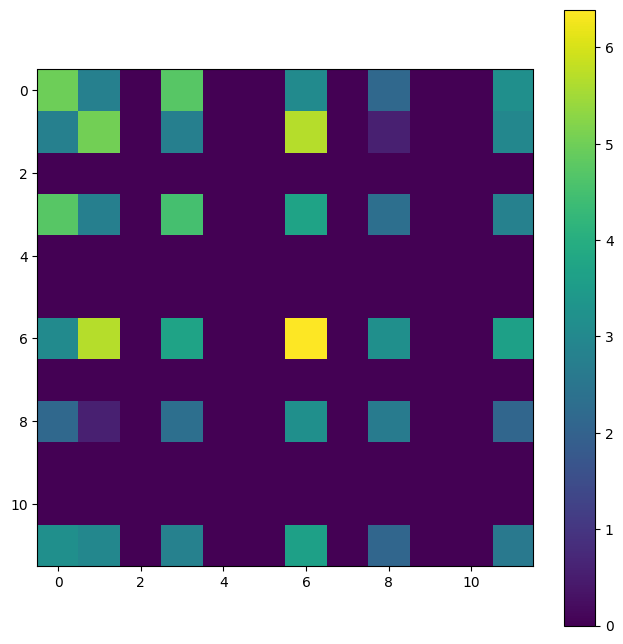

In [10]:
fisher = model.mag_fisher(scobs, params, covmat)
plt.figure(figsize=(8, 8))
plt.imshow(np.log10(np.abs(fisher) + 1), interpolation=None)
plt.colorbar()
plt.show()

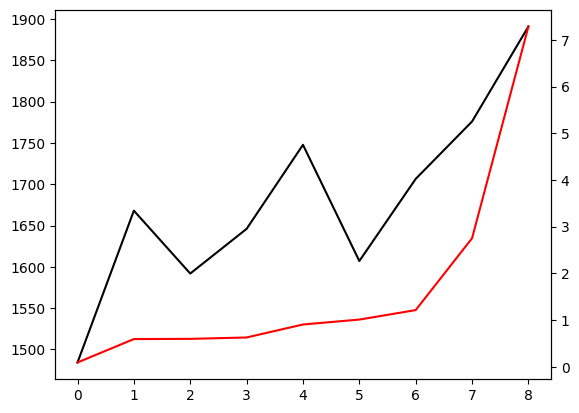

In [27]:
# observations without observations
scobs_obs = MagScObs(
    [14400 + i * 3600 * (16 / (sc_count - 1)) for i in range(sc_count)],
    [[1.0, 0.0, 0.0] for _ in range(sc_count)],
    output
)

pf_abc = model.new_pf(scobs_obs, N, 43, simulation_time_limit=5, simulation_ensemble_size_factor=4, max_iterations=8)
pf_abc.mag_initialize("rmse", 1.0)
particles_initial = pf_abc.particles()
noise_model = ObserVecNoise.gaussian(noise_std)
result_abc = []
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.9, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.8, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.7, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.6, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.5, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.4, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.3, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.2, noise_model)))
result_abc.append(np.array(pf_abc.mag_abc("rmse", 0.1, noise_model)))
result_abc = np.array(result_abc)

particles_abc = pf_abc.particles()



fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_abc[:, 0], color="k")
ax2.plot(result_abc[:, 1], color="r")
plt.show()

abc_min = pf_abc.particles()[0][np.argmin(pf_abc.errors())]

In [28]:
pf_dev = model.new_pf(scobs_obs, N, 42, simulation_time_limit=5, simulation_ensemble_size_factor=4, max_iterations=8)
pf_dev.mag_initialize_rmse(1.0)
result_dev = np.array(pf_dev.mag_dev_rmse(2000, 0.1, 0.9))
particles_dev = pf_dev.particles()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_dev, color="k")
plt.show()

dev_min = pf_dev.particles()[0][np.argmin(pf_dev.errors())]

AttributeError: 'builtins.ECHParticleFilter' object has no attribute 'mag_initialize_rmse'

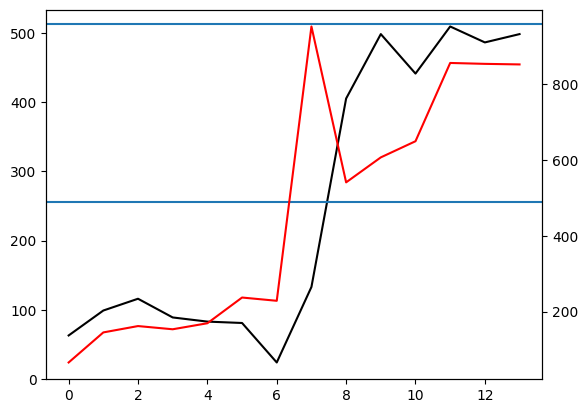

In [ ]:
# restart abc for sir
pf_sir = model.new_pf(scobs_obs, N, 43, simulation_time_limit=5, simulation_ensemble_size_factor=4, max_iterations=8)
pf_sir.mag_initialize_rmse(1.0)
noise_model_sir = ObserVecNoise.gaussian(noise_std)
pf_sir.mag_abc_rmse(noise_model_sir)

result_sir = []

cfl = [10, 5, 4, 3, 2, 1, 0.5, 0.5, 0.25, 0.2, 0.15, 0.1, 0.1, 0.1]

for cf in cfl:
    covmat_mvllh = CovMatrix(np.diag([cf * noise_std ** 2 for _ in range(len(output))]))
    result_sir.append(pf_sir.mag_sir_iter_mvllh(covmat_mvllh))

result_sir = np.array(result_sir).T

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_sir[0, :], color="k")
ax2.plot(result_sir[1, :], color="r")
ax1.axhline(y=512)
ax1.axhline(y=256)
plt.show()

particles_sir = pf_sir.particles()

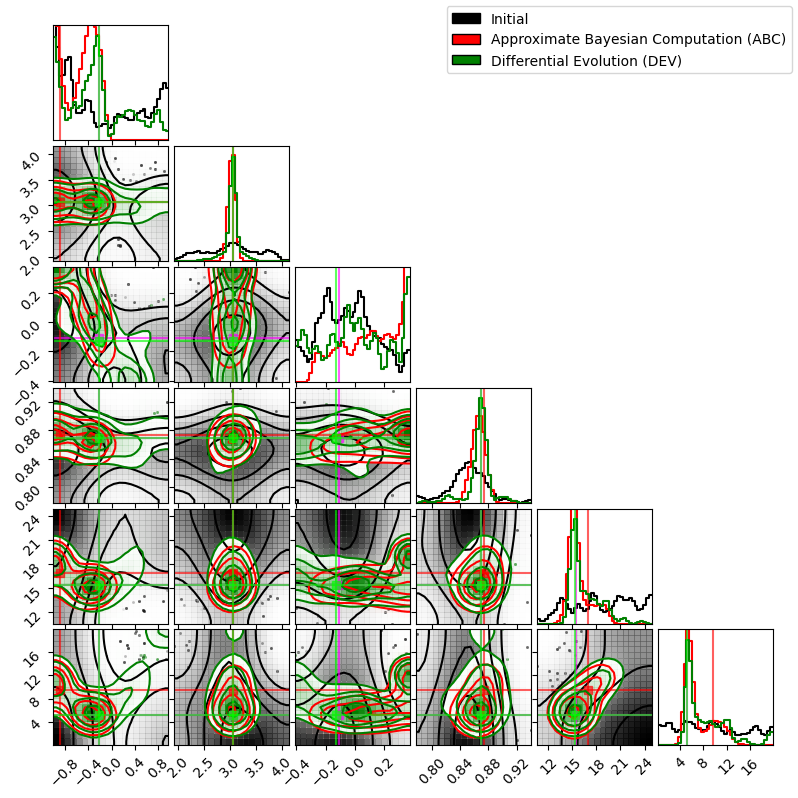

In [ ]:
truths = np.array([-0.22, 3.06, 0.0, -0.11, 1.0, 0.11, 0.87, 500.0, 15.4, 0.0, 0.0, 5.2])

autorange = np.array([np.min(particles_initial[0], axis=0), np.max(particles_initial[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_initial[0].T[autoflag].T, 
              weights=particles_initial[1], color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=truths[autoflag], truth_color='#ff00ffa0')
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=abc_min[autoflag], truth_color='#ff0000a0')
corner.corner(particles_dev[0].T[autoflag].T, 
              weights=particles_dev[1], color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=dev_min[autoflag], truth_color='#00ff00a0')
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Differential Evolution (DEV)"),
], loc='upper right')
plt.show()

/Users/ajweiss/Projects/ocnus/conda/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3430: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/ajweiss/Projects/ocnus/conda/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3430: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/ajweiss/Projects/ocnus/conda/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3430: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/var/folders/7p/smkx6gpj7wggnd2d_96ywpr80000gp/T/ipykernel_93748/3549327839.py:9: RuntimeWarning: divide by zero encountered in dot
  samples = np.random.multivariate_normal(truths[autoflag], inverse[autoflag][:, autoflag], N)
/var/folders/7p/smkx6gpj7wggnd2d_96ywpr80000gp/T/ipykernel_93748/3549327839.py:9: RuntimeWarning: overflow encountered in dot
  samples = np.random.multivariate_normal(truths[autoflag], inverse[autoflag][:, autoflag], N)
/var/folders/7p/smkx6gpj7

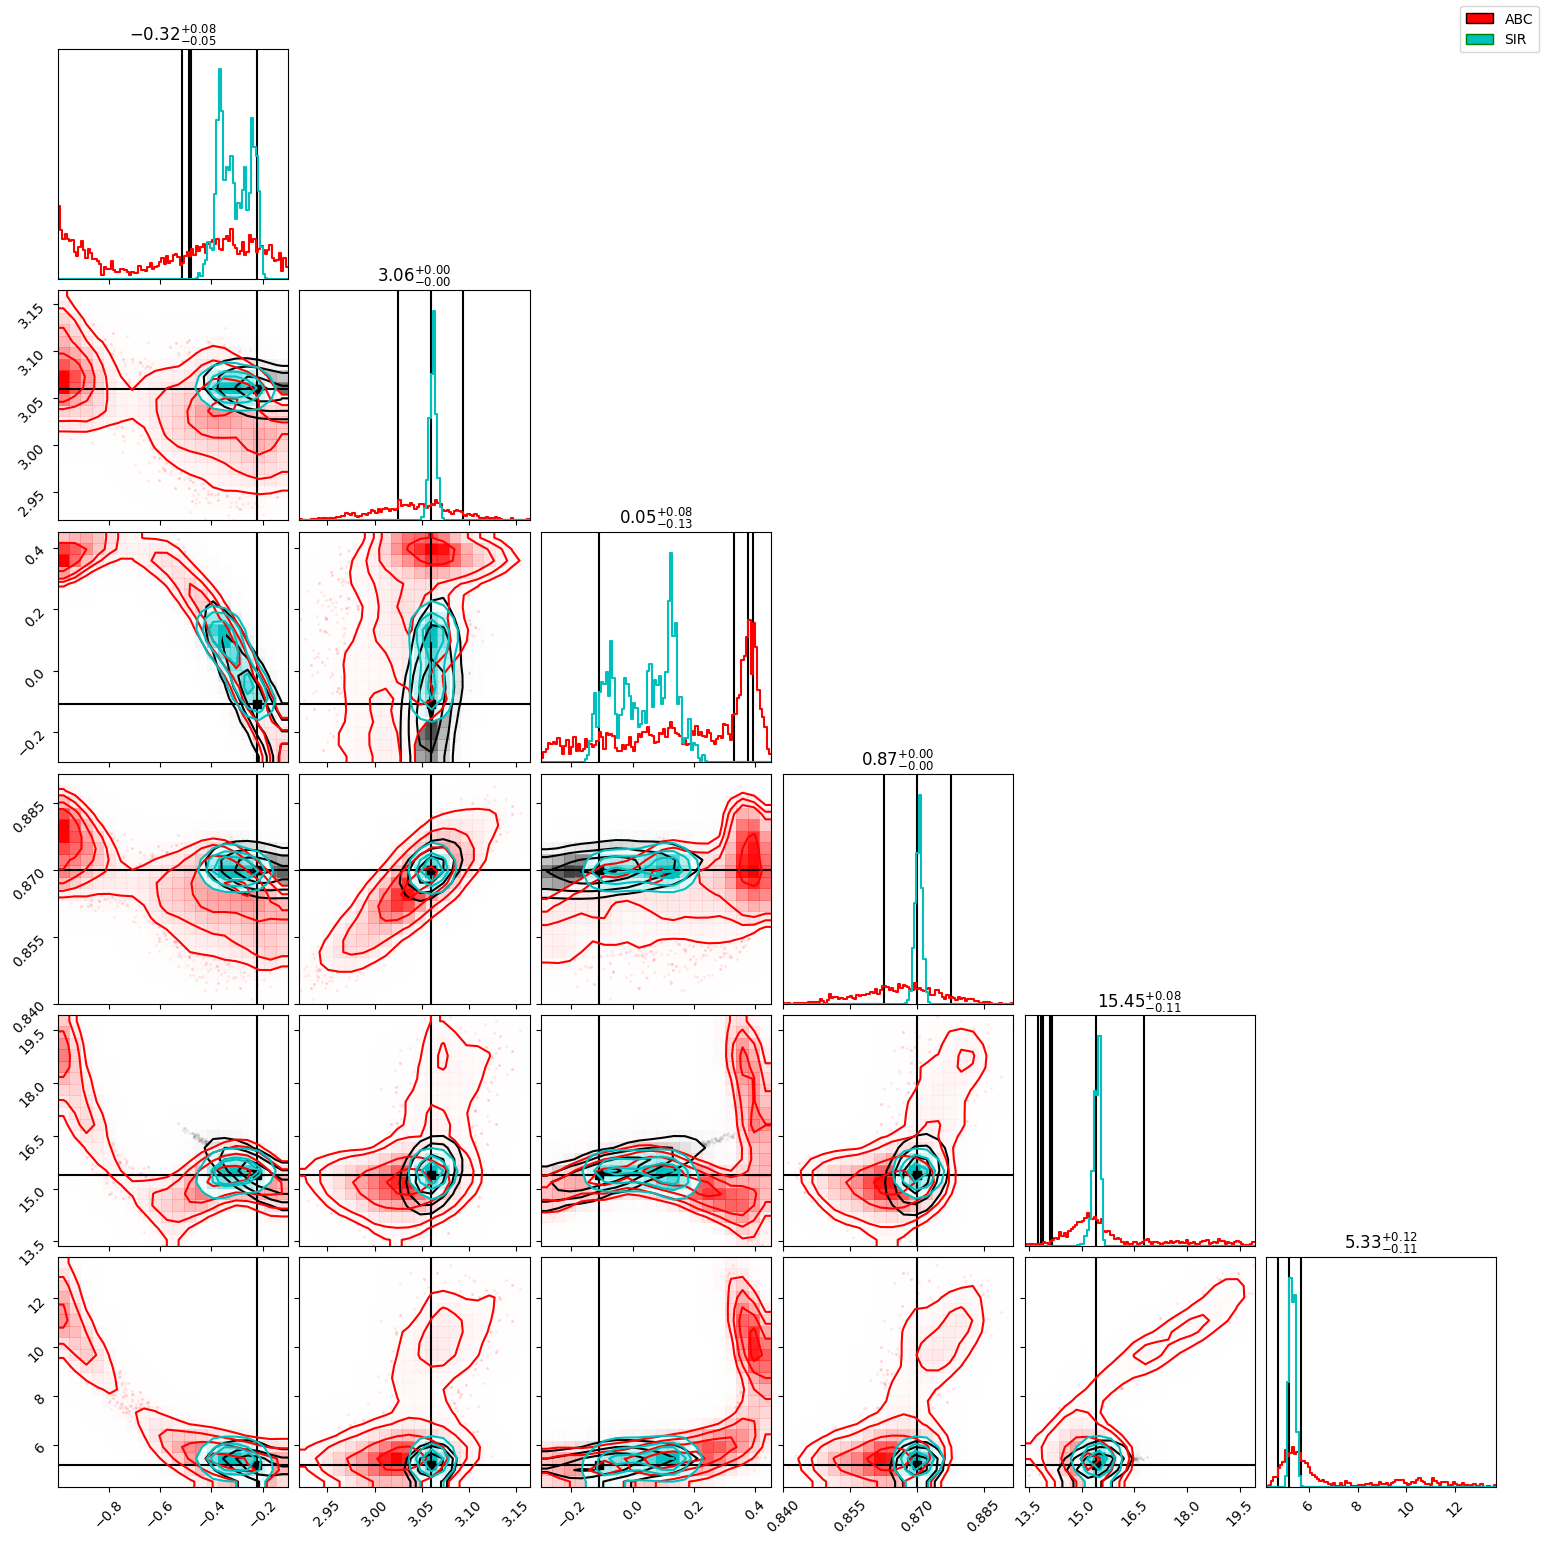

In [ ]:
autorange = np.array([np.min(particles_abc[0], axis=0), np.max(particles_abc[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

inverse = np.linalg.pinv(fisher)
samples = np.random.multivariate_normal(truths[autoflag], inverse[autoflag][:, autoflag], N)
               
cfig = plt.figure(figsize=(16, 16))
corner.corner(samples, 
              color='k',
              range=autorange[autoflag], fig=cfig, smooth=1.0, 
              smooth1d=0.5, bins=20, hist_bin_factor=5, truths=truths[autoflag], truth_color='k')
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=1.0, 
              smooth1d=0.5, bins=20, hist_bin_factor=5, alpha=0.5)
corner.corner(particles_sir[0].T[autoflag].T, 
              weights=particles_sir[1], color='c',
              range=autorange[autoflag], fig=cfig, smooth=1.0,
              smooth1d=0.5, bins=20, hist_bin_factor=5, show_titles=True, alpha=0.5)
cfig.legend(handles=[
    Patch(facecolor='r', edgecolor='k', label="ABC"),
    Patch(facecolor='c', edgecolor='g', label="SIR")
], loc='upper right')
plt.show()